# Training Exponential Saturation Model for BranchSherpa

## Description

BranchSherpa uses exponential Saturation model to describe the relationship between branch entropy and branch miss rate.

The exponential saturaion model is expressed as:

$$
\mathrm{Miss}(e) = m_0 + M\left(1 - e^{-ke}\right)
$$

where $e$ is branch entropy, $m_0$ is the baseline branch miss rate, $M$ controls the saturation range, and $k$ controls how quickly the model approaches saturation.

The model is trained on the training dataset by minimizing the Mean Squared Error (MSE) using Adam optimizer.
Its prediction accuracy is then evaluated on the held-out test dataset and compared with the previously derived LBE's linear regression model.



### Step 1: Imports and Configuration

In [8]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

# Input CSV files
# Please Update these two paths if you would like to evaluated your predictor
TRAIN_CSV   = Path("../dataset/branchsherpa/bimode_train.csv")
TEST_CSV    = Path("../dataset/branchsherpa/bimode_test.csv")

# Exponential saturation training configuration
NUM_STEPS = 7000
LEARNING_RATE = 1e-2

### Step 2: Loading the Training and Test Datasets

In [9]:
def load_dataset(csv_path):
    data = np.loadtxt(
        csv_path,
        delimiter=",",
        skiprows=1,
        ndmin=2
    )

    if data.shape[1] != 2:
        raise ValueError(
            f"{csv_path} must contain exactly two columns: "
            "branch_entropy and branch_miss_rate."
        )

    if not np.isfinite(data).all():
        raise ValueError(f"{csv_path} contains NaN or infinite values.")

    entropy = torch.tensor(data[:, 0], dtype=torch.float32).reshape(-1, 1)
    branch_miss_rate = torch.tensor(data[:, 1], dtype=torch.float32).reshape(-1, 1)

    return entropy, branch_miss_rate

x_train, y_train    = load_dataset(TRAIN_CSV)
x_test, y_test      = load_dataset(TEST_CSV)

print(f"Number of training samples (branch entropy) : {len(x_train)}") 
print(f"Number of training samples (branch miss rate) : {len(y_train)}") 

print(f"Number of test samples (branch entropy) : {len(x_test)}")
print(f"Number of test samples (branch miss rate) : {len(y_test)}")

Number of training samples (branch entropy) : 40
Number of training samples (branch miss rate) : 40
Number of test samples (branch entropy) : 5
Number of test samples (branch miss rate) : 5


### Step 3: Defining the LBE Lineaer Regression Baseline

In [10]:
# Update the model if you have trained different one
def linear(x):
    return 224.38 * x + 1.73

### Step 4: Defining and Training the Exponential Saturation Model

In [11]:
class ExpSat(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.m0 = torch.nn.Parameter(torch.tensor(0.5, dtype=torch.float32))
        self.M = torch.nn.Parameter(torch.tensor(8.0, dtype=torch.float32))
        self.k = torch.nn.Parameter(torch.tensor(40.0, dtype=torch.float32))

    def forward(self, x):
        return self.m0 + self.M * (1 - torch.exp(-self.k * x))

exp_model = ExpSat()
optimizer = torch.optim.Adam(exp_model.parameters(), lr=LEARNING_RATE)

exp_train_loss = []

for step in range(1, NUM_STEPS + 1):
    pred = exp_model(x_train)
    loss = torch.mean((pred - y_train) ** 2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    exp_train_loss.append(loss.item())

m0 = exp_model.m0.item()
M = exp_model.M.item()
k = exp_model.k.item()

print(
    f"Exponential saturation model: "
    f"miss(e) = {m0:.4f} + {M:.4f} * (1 - exp(-{k:.4f} * e))"
)

Exponential saturation model: miss(e) = 1.3318 + 38.9776 * (1 - exp(-8.3294 * e))


### Step5: Evaluating the Models on the Test Dataset

In [13]:
with torch.no_grad():
    pred_exp_test = exp_model(x_test)

pred_lin_test = linear(x_test)

def get_metrics(y_true, y_pred):
    mae = torch.mean(torch.abs(y_true - y_pred)).item()
    mse = torch.mean((y_true - y_pred) ** 2).item()
    return mae, mse

mae_exp, mse_exp = get_metrics(y_test, pred_exp_test)
mae_lin, mse_lin = get_metrics(y_test, pred_lin_test)

print("=============== Test Metrics ===============")
print(f"Exponential Saturation -> MAE: {mae_exp:.4f}, MSE: {mse_exp:.4f}")
print(f"Linear Regression      -> MAE: {mae_lin:.4f}, MSE: {mse_lin:.4f}")

print("\n=== Per-Sample Absolute Errors ===")
for i in range(len(x_test)):
    e_val = x_test[i].item()
    true_y = y_test[i].item()
    exp_y = pred_exp_test[i].item()
    lin_y = pred_lin_test[i].item()

    exp_err = abs(true_y - exp_y)
    lin_err = abs(true_y - lin_y)

    print(
        f"[{i}] entropy={e_val:.6f} | "
        f"true={true_y:.4f} | "
        f"exp={exp_y:.4f} (err={exp_err:.4f}) | "
        f"linear={lin_y:.4f} (err={lin_err:.4f})"
    )


=============== Test Metrics ===============
Exponential Saturation -> MAE: 2.1410, MSE: 9.3148
Linear Regression      -> MAE: 3.1389, MSE: 12.2664

=== Per-Sample Absolute Errors ===
[0] entropy=0.124567 | true=25.0333 | exp=26.4991 (err=1.4657) | linear=29.6803 (err=4.6470)
[1] entropy=0.105975 | true=30.5133 | exp=24.1859 (err=6.3274) | linear=25.5087 (err=5.0046)
[2] entropy=0.032121 | true=10.8970 | exp=10.4817 (err=0.4153) | linear=8.9373 (err=1.9597)
[3] entropy=0.009215 | true=4.7178 | exp=4.2116 (err=0.5062) | linear=3.7977 (err=0.9201)
[4] entropy=0.068653 | true=20.2972 | exp=18.3071 (err=1.9901) | linear=17.1344 (err=3.1628)


### Step 6: Visualizing the Fitted Models and Training Loss

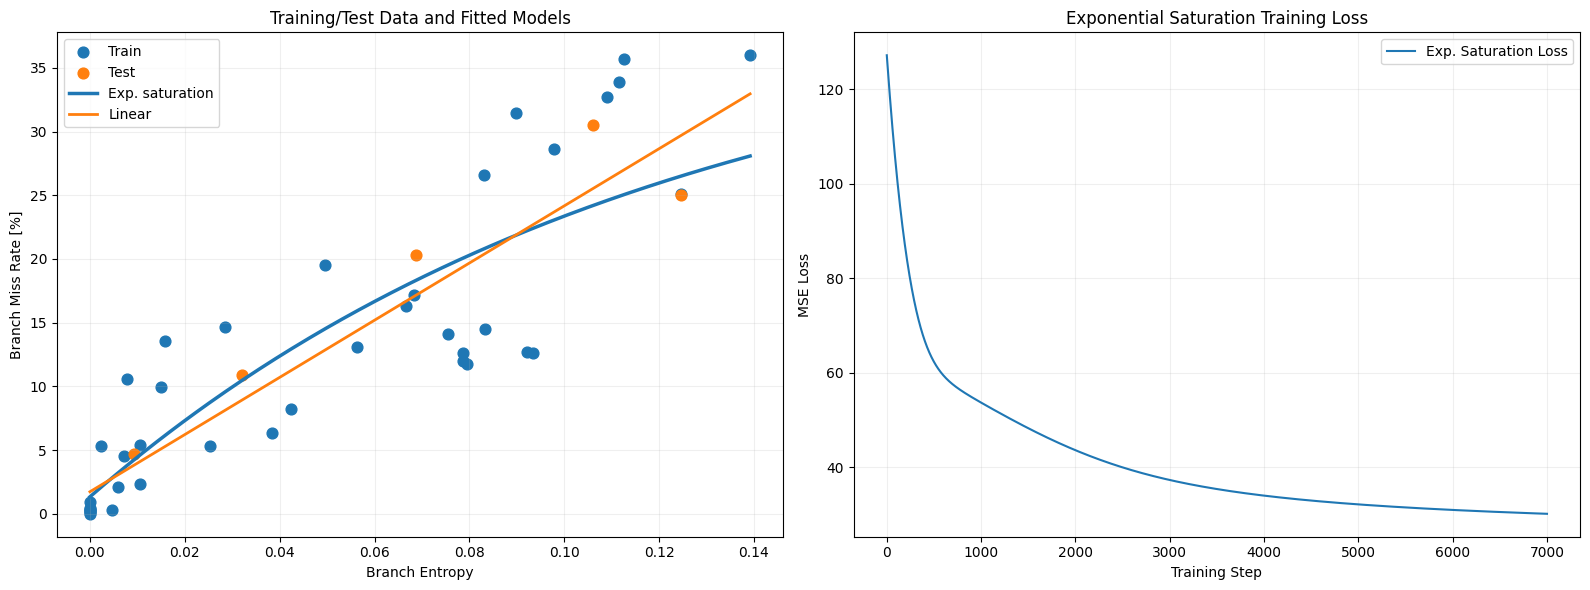

In [14]:
def visualize():
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.scatter(x_train.numpy(), y_train.numpy(), label="Train", s=60)
    plt.scatter(x_test.numpy(), y_test.numpy(), label="Test", s=60)

    # x_min = float(torch.min(torch.cat([x_train, x_test], dim=0)))
    # x_max = float(torch.max(torch.cat([x_train, x_test], dim=0)))
    x_min = min(x_train.min().item(), x_test.min().item())
    x_max = max(x_train.max().item(), x_test.max().item())
    x_range = np.linspace(x_min, x_max, 200)

    y_exp = m0 + M * (1 - np.exp(-k * x_range))
    y_lin = linear(x_range)

    plt.plot(x_range, y_exp, label='Exp. saturation', linewidth=2.5)
    plt.plot(x_range, y_lin, label='Linear', linewidth=2)

    plt.xlabel("Branch Entropy")
    plt.ylabel("Branch Miss Rate [%]")
    plt.title("Training/Test Data and Fitted Models")
    plt.legend()
    plt.grid(True, alpha=0.2)

    plt.subplot(1, 2, 2)
    plt.plot(exp_train_loss, label="Exp. Saturation Loss")
    plt.xlabel("Training Step")
    plt.ylabel("MSE Loss")
    plt.title("Exponential Saturation Training Loss")
    plt.grid(True, alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

visualize()
